<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
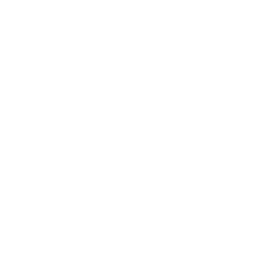
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Κωδικοποίηση Ανεπιθύμητων Συμβάντων Κλινικής Δοκιμής</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτική / Επιτήρηση Ασφάλειας Φαρμάκων &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Τα σύνολα δεδομένων ανεπιθύμητων συμβάντων φτάνουν με αυτούσιους προτιμώμενους όρους MedDRA, αλλά
οι κανονιστικοί πίνακες ασφάλειας οργανώνονται ανά Κατηγορία Οργανικού Συστήματος (ΚΟΣ). Αυτό
το παράδειγμα δημιουργεί μια μορφή τιμών PROC FORMAT που αντιστοιχίζει κάθε προτιμώμενο όρο στην
ΚΟΣ του, και στη συνέχεια χρησιμοποιεί αυτή τη μοναδική μορφή για να οδηγήσει κάθε επόμενη
πινακοποίηση: μια διασταύρωση PROC FREQ της ΚΟΣ ανά σκέλος θεραπείας, μια ανάλυση ΚΟΣ ανά
σοβαρότητα, και μια σύνοψη σοβαρών ανεπιθύμητων συμβάντων. Επειδή η αντιστοίχιση βρίσκεται μόνο
σε αυτή τη μορφή, η επανακωδικοποίηση της δοκιμής σε νέα έκδοση MedDRA είναι μια μεμονωμένη
επεξεργασία της μορφής και όχι επανασυγγραφή κάθε αναφοράς. Το ODS OUTPUT καταγράφει τις
συχνότητες ΚΟΣ ως σύνολο δεδομένων για κατάντη ανασκόπηση σημάτων.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------:|
| WORK.AE_RAW | Συνθετικές εγγραφές ανεπιθύμητων συμβάντων με προτιμώμενους όρους MedDRA | 100 |
| WORK.RANDOMIZATION | Αναθέσεις σκέλους θεραπείας ανά υποκείμενο | 100 |

Το περιβάλλον εκτελείται χωρίς άδεια χρήσης, οπότε κάθε παραγόμενος πίνακας περιορίζεται σε 100
παρατηρήσεις. Το σενάριο έχει διαστασιολογηθεί σε αυτό το όριο: 100 ανεπιθύμητα συμβάντα από
ένα σύνολο 12 όρων MedDRA, τυπικό για μια ογκολογική δοκιμή.


---


In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού συνόλου δεδομένων ανεπιθύμητων συμβάντων
   Προτιμώμενοι όροι MedDRA αντιστοιχισμένοι σε κατηγορίες ΚΟΣ
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.ae_raw;
    CALL streaminit(42);
    LENGTH aedecod $70 aesev $20;
    ARRAY pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        ΕΑΝ pt_idx = 1 ΤΟΤΕ aedecod = 'Ναυτία';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 2 ΤΟΤΕ aedecod = 'Πονοκέφαλος';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 3 ΤΟΤΕ aedecod = 'Έμετος';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 4 ΤΟΤΕ aedecod = 'Διάρροια';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 5 ΤΟΤΕ aedecod = 'Βήχας';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 6 ΤΟΤΕ aedecod = 'Κόπωση';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 7 ΤΟΤΕ aedecod = 'Αρθραλγία';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 8 ΤΟΤΕ aedecod = 'Πυρετός';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 9 ΤΟΤΕ aedecod = 'Κοιλιακό άλγος';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 10 ΤΟΤΕ aedecod = 'Ουδετεροπενία';
        ΑΛΛΙΩΣ ΕΑΝ pt_idx = 11 ΤΟΤΕ aedecod = 'Εμπύρετη ουδετεροπενία';
        ΑΛΛΙΩΣ aedecod = 'Αντίδραση σχετιζόμενη με την έγχυση';
        sev_idx = int(rand('uniform') * 3) + 1;
        ΕΑΝ pt_idx IN (10, 11) ΤΟΤΕ sev_idx = MAX(sev_idx, 2);
        ΕΑΝ sev_idx = 1 ΤΟΤΕ aesev = 'ΗΠΙΑ';
        ΑΛΛΙΩΣ ΕΑΝ sev_idx = 2 ΤΟΤΕ aesev = 'ΜΕΤΡΙΑ';
        ΑΛΛΙΩΣ aesev = 'ΣΟΒΑΡΗ';
        aeser = ifc(aesev = 'ΣΟΒΑΡΗ' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        ΕΑΝ aestdy > 365 ΤΟΤΕ aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i pt_idx sev_idx;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.77 seconds
  cpu   1.77 seconds


In [2]:
/* --------------------------------------------------------
   Δημιουργία πίνακα τυχαιοποίησης υποκειμένων
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.randomization;
    CALL streaminit(43);
    LENGTH treatment_arm $40;
    ΕΠΑΝΑΛΗΨΗ subject_id = 1 ΕΩΣ 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        ΕΑΝ arm_idx = 1 ΤΟΤΕ treatment_arm = 'Πειραματική Αγωγή';
        ΑΛΛΙΩΣ ΕΑΝ arm_idx = 2 ΤΟΤΕ treatment_arm = 'Ενεργό Συγκριτικό';
        ΑΛΛΙΩΣ treatment_arm = 'Εικονικό Φάρμακο';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ arm_idx;
    ΜΟΡΦΗ randomization_date date9.;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---


                              Ακατέργαστη Συχνότητα Προτιμώμενου Όρου (Μη Χαρτογραφημένη)                               

                                                   The FREQ Procedure

Προτιμώμενος Όρος                                                     Frequency    Percent
-------------------------------------------------------------------------------------------
Διάρροια                                                                     12     12.00
Πονοκέφαλος                                                                  12     12.00
Κόπωση                                                                       11     11.00
Πυρετός                                                                      11     11.00
Αρθραλγία                                                                    10     10.00
Ναυτία                                                                       10     10.00
Αντίδραση σχετιζόμενη με την έγχυση                                           8     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


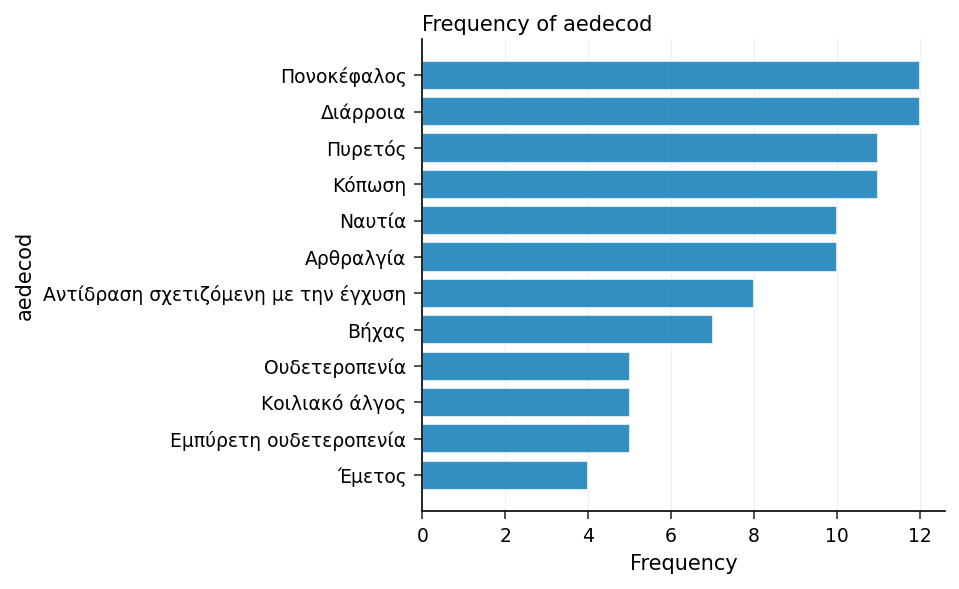

In [3]:
/* --------------------------------------------------------
   Συχνότητα προτιμώμενου όρου πριν την αντιστοίχιση σε ΚΟΣ
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.ae_raw ORDER=ΣΥΧΝΟΤΗΤΕΣ;
    TABLES aedecod / nocum;
    ΕΤΙΚΕΤΑ aedecod='Προτιμώμενος Όρος';
    TITLE 'Ακατέργαστη Συχνότητα Προτιμώμενου Όρου (Μη Χαρτογραφημένη)';
ΕΚΤΕΛΕΣΗ;


---


                              Ακατέργαστη Συχνότητα Προτιμώμενου Όρου (Μη Χαρτογραφημένη)                               




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


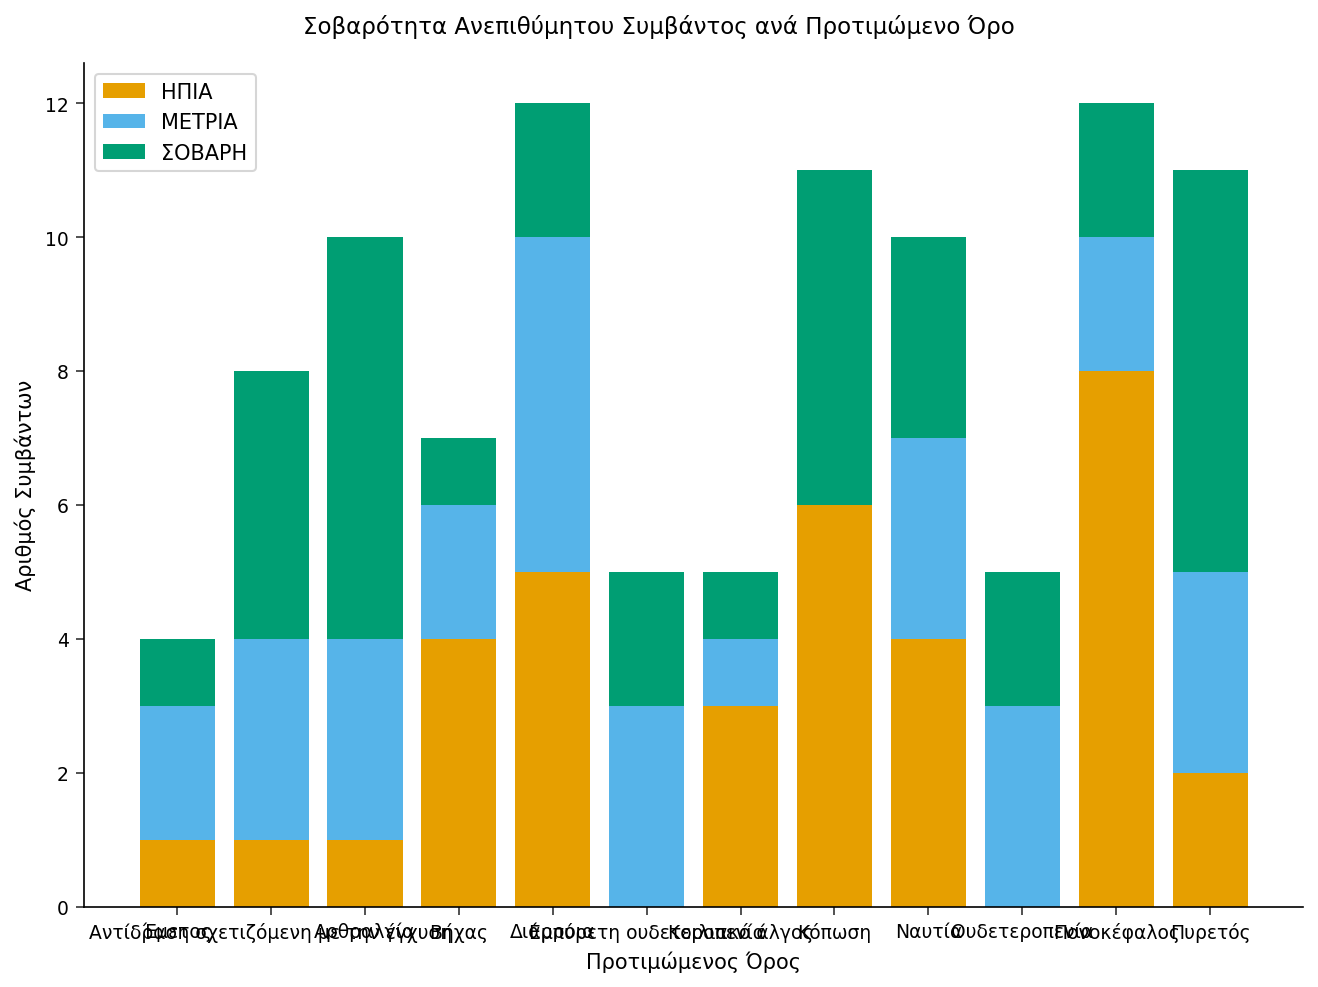

In [4]:
/* --------------------------------------------------------
   Κατανομή σοβαρότητας ανεπιθύμητων συμβάντων ανά προτιμώμενο όρο
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ΕΤΙΚΕΤΑ='Προτιμώμενος Όρος' fitpolicy=ROTATE;
    YAXIS ΕΤΙΚΕΤΑ='Αριθμός Συμβάντων';
    TITLE 'Σοβαρότητα Ανεπιθύμητου Συμβάντος ανά Προτιμώμενο Όρο';
ΕΚΤΕΛΕΣΗ;


---


In [5]:
/* --------------------------------------------------------
   Ορισμός της μορφής τιμών προτιμώμενος όρος MedDRA -> Κατηγορία
   Οργανικού Συστήματος. Η μορφή είναι κλειδωμένη στο κείμενο του
   προτιμώμενου όρου, ώστε μία μόνο κλήση PUT() να κωδικοποιεί
   κάθε εγγραφή ΑΣ στην ΚΟΣ της.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΟΡΦΗ;
    VALUE $pt_to_soc
        'Ναυτία'                              = 'Γαστρεντερικές διαταραχές'
        'Έμετος'                               = 'Γαστρεντερικές διαταραχές'
        'Διάρροια'                             = 'Γαστρεντερικές διαταραχές'
        'Κοιλιακό άλγος'                       = 'Γαστρεντερικές διαταραχές'
        'Πονοκέφαλος'                          = 'Διαταραχές νευρικού συστήματος'
        'Κόπωση'                               = 'Γενικές διαταραχές'
        'Πυρετός'                              = 'Γενικές διαταραχές'
        'Βήχας'                                = 'Αναπνευστικές διαταραχές'
        'Αρθραλγία'                            = 'Διαταραχές μυοσκελετικού συστήματος'
        'Ουδετεροπενία'                        = 'Διαταραχές αίματος και λεμφικού συστήματος'
        'Εμπύρετη ουδετεροπενία'               = 'Διαταραχές αίματος και λεμφικού συστήματος'
        'Αντίδραση σχετιζόμενη με την έγχυση'  = 'Διαταραχές ανοσοποιητικού συστήματος'
        OTHER                                  = 'Μη κωδικοποιημένο'
    ;
    VALUE $sev_rank
        'ΗΠΙΑ'   = '1-Ήπια'
        'ΜΕΤΡΙΑ' = '2-Μέτρια'
        'ΣΟΒΑΡΗ' = '3-Σοβαρή'
        OTHER    = '9-Άγνωστη'
    ;
    VALUE $serious_fmt
        'Y' = 'Σοβαρό'
        'N' = 'Μη Σοβαρό'
    ;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Συγχώνευση εγγραφών ΑΣ με σκέλος θεραπείας και εφαρμογή της
   μορφής ΚΟΣ. Το PUT(aedecod, $pt_to_soc.) είναι το μοναδικό
   βήμα αντιστοίχισης· η σοβαρότητα και το αν είναι σοβαρό
   κωδικοποιούνται με τον ίδιο τρόπο.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.ae_raw; ΚΑΤΑ usubjid; ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.randomization; ΚΑΤΑ usubjid; ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.ae_coded;
    LENGTH soc_class $100 severity_rank $30 serious_flag $30;
    ΣΥΓΧΩΝΕΥΣΗ work.ae_raw (IN=a)
          work.randomization (IN=b ΚΡΑΤΗΣΗ=usubjid treatment_arm);
    ΚΑΤΑ usubjid;
    ΕΑΝ a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
    ΕΤΙΚΕΤΑ soc_class='Κατηγορία Οργανικού Συστήματος'
          severity_rank='Κατάταξη Σοβαρότητας'
          serious_flag='Σοβαρό Συμβάν'
          treatment_arm='Σκέλος Θεραπείας'
          aedecod='Προτιμώμενος Όρος'
          aesev='Σοβαρότητα';
ΕΚΤΕΛΕΣΗ;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                          Επίπτωση ΑΣ ανά Κατηγορία Οργανικού Συστήματος και Σκέλος Θεραπείας                           

                                                   The FREQ Procedure

Table of Κατηγορία Οργανικού Συστήματος by Σκέλος Θεραπείας

Κατηγορία Οργανικού Συστήματος                                                   |                 Εικονικό Φάρμακο |                Ενεργό Συγκριτικό |                Πειραματική Αγωγή |                             Total
---------------------------------------------------------------------------------+----------------------------------+----------------------------------+----------------------------------+----------------------------------
Γαστρεντερικές διαταραχές                                                        |                                2 |                                1 |                                0 |                                 3
--------------------------------------------------------------------------------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


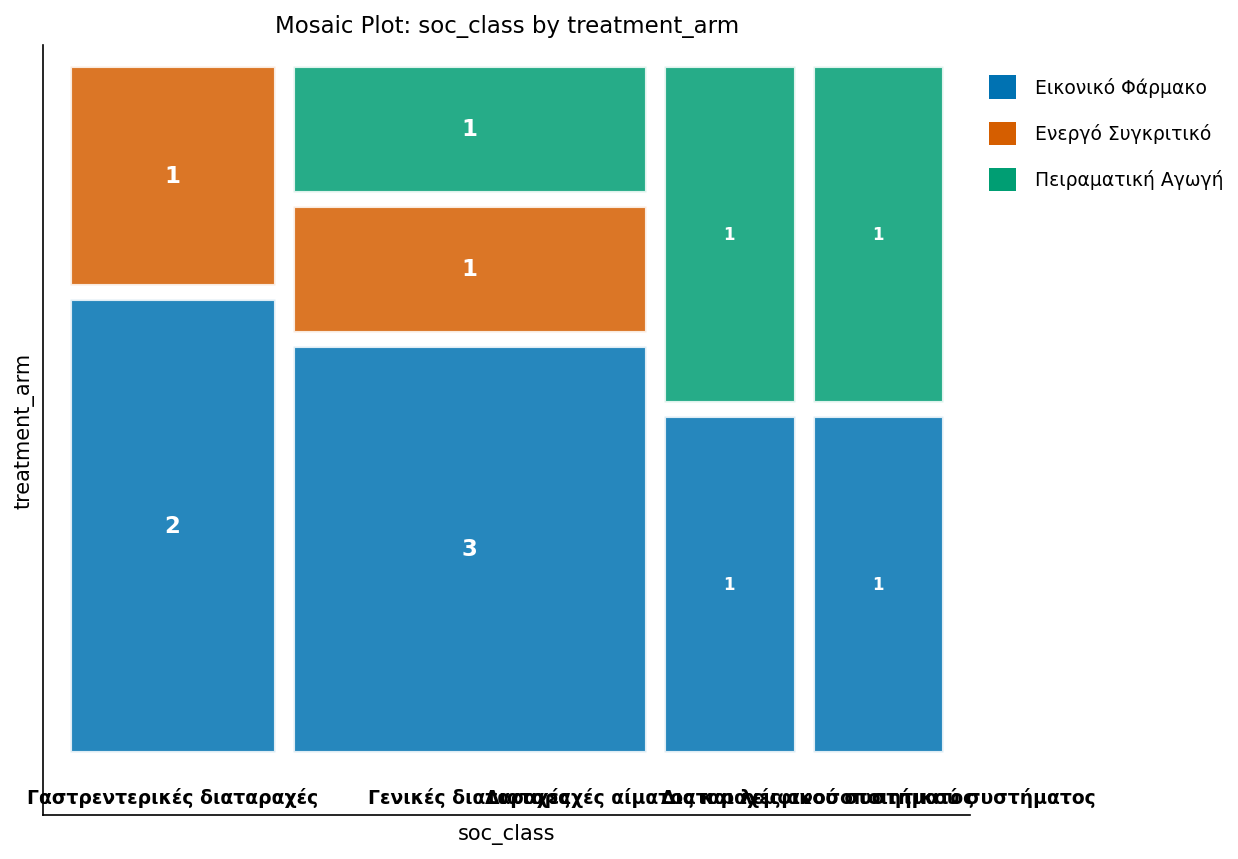

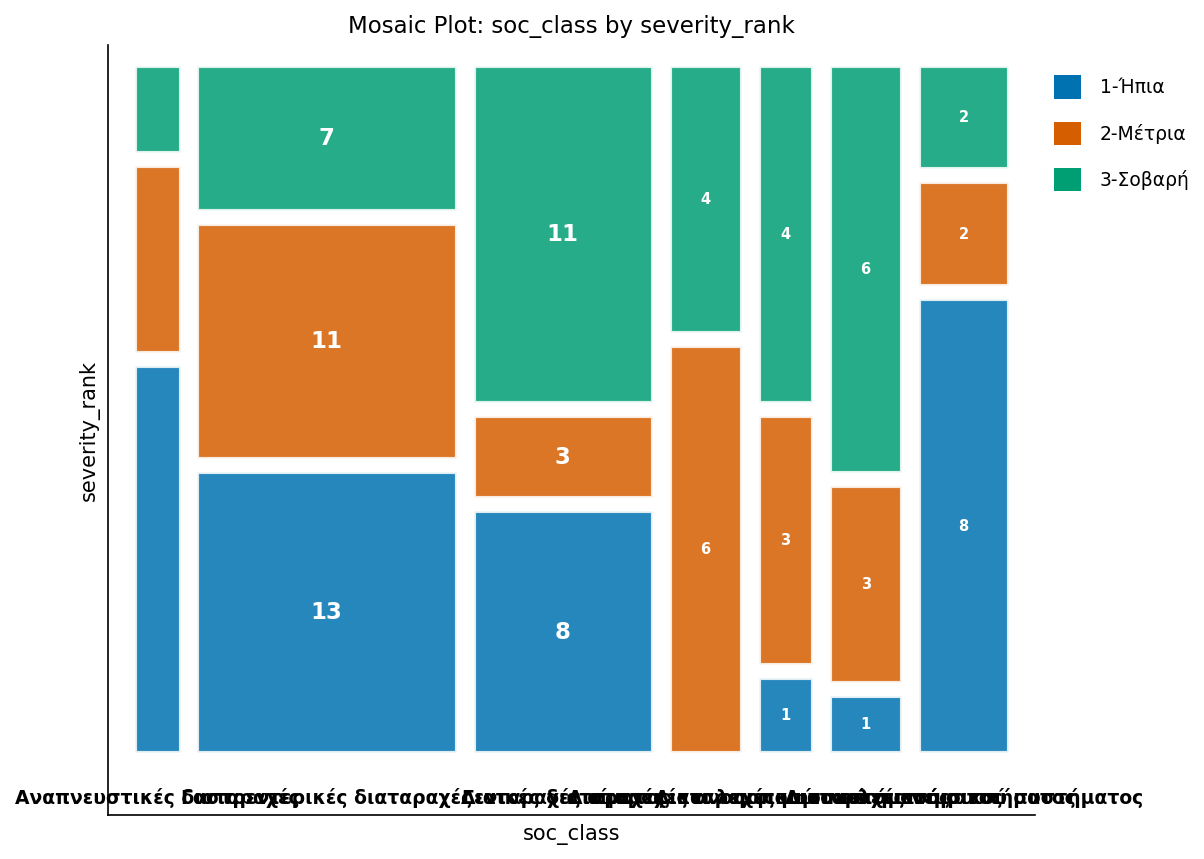

In [7]:
/* --------------------------------------------------------
   Συχνότητα σε επίπεδο ΚΟΣ ανά σκέλος θεραπείας
   Το ODS OUTPUT καταγράφει τα αποτελέσματα για ανίχνευση σημάτων
   -------------------------------------------------------- */
ODS ΕΞΟΔΟΣ onewayfreqs=work.soc_freq_table;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.ae_coded ORDER=ΣΥΧΝΟΤΗΤΕΣ;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    TITLE 'Επίπτωση ΑΣ ανά Κατηγορία Οργανικού Συστήματος και Σκέλος Θεραπείας';
ΕΚΤΕΛΕΣΗ;

ODS ΕΞΟΔΟΣ CLOSE;


                                Σοβαρά Ανεπιθύμητα Συμβάντα ανά ΚΟΣ και Σκέλος Θεραπείας                                

                                                   The FREQ Procedure

Table of Κατηγορία Οργανικού Συστήματος by Σκέλος Θεραπείας

Κατηγορία Οργανικού Συστήματος                                         |                 Εικονικό Φάρμακο |                Ενεργό Συγκριτικό |                Πειραματική Αγωγή |                             Total
-----------------------------------------------------------------------+----------------------------------+----------------------------------+----------------------------------+----------------------------------
Γενικές διαταραχές                                                     |                                1 |                                1 |                                1 |                                 3
-----------------------------------------------------------------------+----------------------------------+---


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


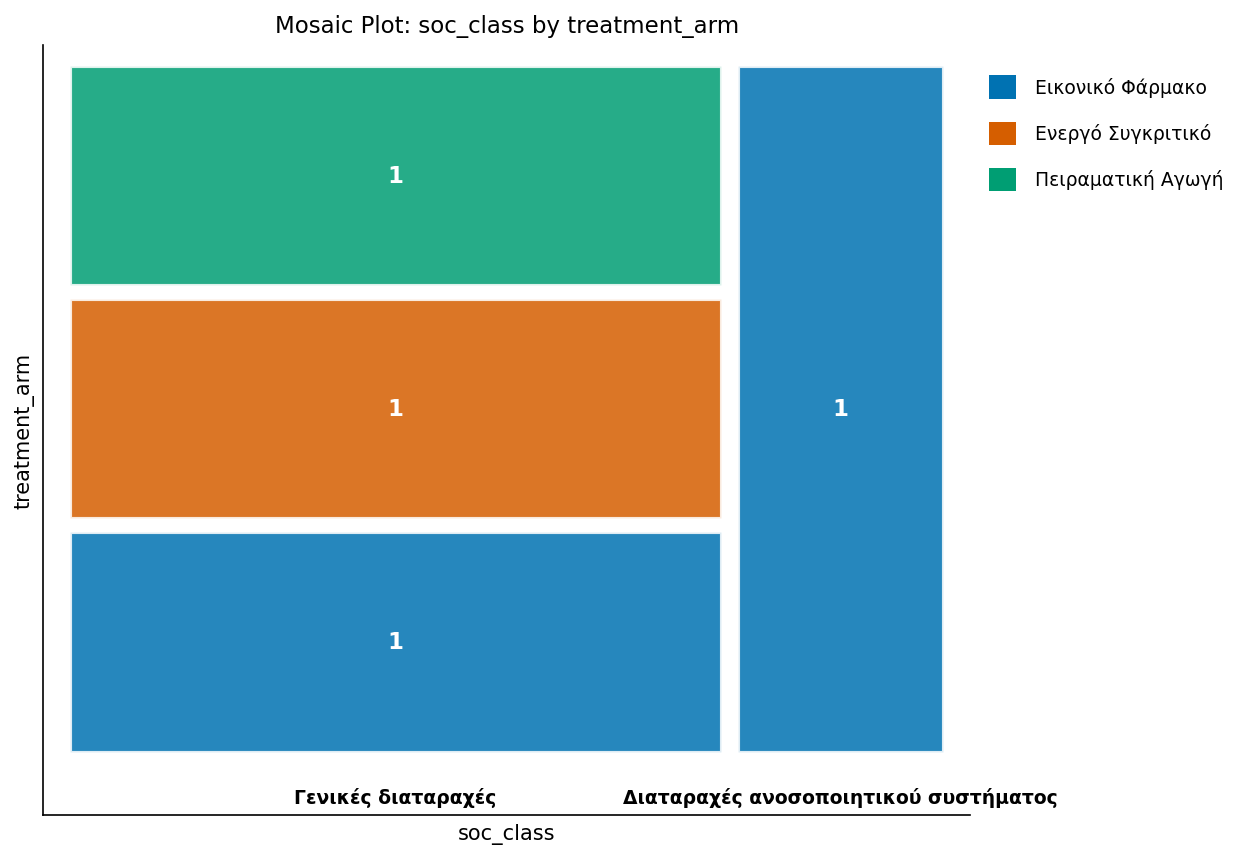

In [8]:
/* --------------------------------------------------------
   Σύνοψη σοβαρών ΑΣ ανά ΚΟΣ για την αφήγηση ασφάλειας
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.ae_coded;
    ΟΠΟΥ aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    TITLE 'Σοβαρά Ανεπιθύμητα Συμβάντα ανά ΚΟΣ και Σκέλος Θεραπείας';
ΕΚΤΕΛΕΣΗ;


---


### Ερμηνεία

Μία μοναδική μορφή τιμών `$pt_to_soc` κωδικοποίησε και τα 100 ανεπιθύμητα συμβάντα από 12
αυτούσιους προτιμώμενους όρους MedDRA σε 7 Κατηγορίες Οργανικού Συστήματος, και αυτή η μία
μορφή οδήγησε κάθε πίνακα παρακάτω χωρίς επανακωδικοποίηση των δεδομένων.

Ανά ΚΟΣ και σοβαρότητα, οι **Γαστρεντερικές διαταραχές** είναι η συχνότερη κατηγορία με 31 από
τα 100 συμβάντα (13 ήπια, 11 μέτρια, 7 σοβαρά), ακολουθούμενη από τις **Γενικές διαταραχές** με
22 συμβάντα. Οι υπόλοιπες κατηγορίες είναι μικρότερες: Διαταραχές νευρικού συστήματος (12),
Διαταραχές αίματος και λεμφικού συστήματος (10), Διαταραχές μυοσκελετικού συστήματος (10),
Διαταραχές ανοσοποιητικού συστήματος (8), και Αναπνευστικές διαταραχές (7). Σε όλα τα συμβάντα
ο διαχωρισμός σοβαρότητας είναι 35 ήπια, 30 μέτρια, και 35 σοβαρά.

Μόνο 4 συμβάντα σημειώθηκαν ως σοβαρά (`aeser='Y'`): 3 στις Γενικές διαταραχές (ένα ανά σκέλος)
και 1 στις Διαταραχές ανοσοποιητικού συστήματος (εικονικό φάρμακο). Η διασταύρωση ΚΟΣ ανά σκέλος
θεραπείας βασίζεται στα 12 συμβάντα των οποίων το υποκείμενο αντιστοιχίστηκε με εγγραφή
τυχαιοποίησης, οπότε οι μετρήσεις ανά σκέλος είναι ενδεικτικές και όχι σχεδιασμένες για μια
σύγκριση μεταξύ σκελών.

Το βασικό συμπέρασμα είναι ο μηχανισμός FORMAT, όχι οι συνθετικοί αριθμοί: επειδή η αντιστοίχιση
προτιμώμενου όρου σε ΚΟΣ βρίσκεται εξ ολοκλήρου στο PROC FORMAT, η ίδια κλήση
`PUT(aedecod, $pt_to_soc.)` επανακωδικοποιεί όλο το σύνολο δεδομένων, και η ενημέρωση σε νέα
έκδοση λεξικού MedDRA σημαίνει επεξεργασία μίας μορφής αντί για κάθε αναφορά. Το ODS OUTPUT
κατέγραψε τις συχνότητες ΚΟΣ ως `work.soc_freq_table` για κατάντη ανασκόπηση σημάτων.


---


In [9]:
/* --------------------------------------------------------
   Εξαγωγή του συνόλου δεδομένων ΑΣ κωδικοποιημένου κατά ΚΟΣ για
   ανασκόπηση σήματος ασφάλειας. Η μοναδική μορφή $pt_to_soc έχει
   συμπληρώσει το soc_class, οπότε το εξαγόμενο αρχείο είναι έτοιμο
   για κατάντη ανάλυση σε επίπεδο ΚΟΣ.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>